In [2]:
# use dfngp_env
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# for reading HDF5 files
import h5py
import os

In [3]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

# Benchmark basal mass balance (bmb) map

## References and links:
- Paper: *Adusumilli, Susheel, et al. "Interannual variations in meltwater input to the Southern Ocean from Antarctic ice shelves." Nature geoscience 13.9 (2020): 616-620.* [Link to paper on Nature.](https://www.nature.com/articles/s41561-020-0616-z)
- [Link to UCSD data repository](https://library.ucsd.edu/dc/object/bb0448974g). Select Component 3 for Antarctic ice shelf melt rates.
    - **Antarctic ice shelf melt rates**: Average basal melt rates for Antarctic ice shelves for the 2010–2018 period at high spatial resolution, estimated using CryoSat-2 data. This data file was last updated on 2020-06-11.
    - Description: Average basal melt rates for Antarctic ice shelves for the 2010–2018 period at high spatial resolution, estimated using CryoSat-2 data. Interpolated values in regions with missing data are provided as a separate field. We are currently working on using ICESat-2 data to improve the estimates over regions with missing CryoSat-2 data.
- [Link to accompanying UCSD Scripps glaciology Github repository](https://github.com/sioglaciology/ice_shelf_change). Refer to *ead_melt_rate_file.ipynb* notebook for the dataset loading pipeline.


## Download data

Via the terminal, navigate to the destination folde to hold the file and and download the file with the following command:  
  
``wget https://library.ucsd.edu/dc/object/bb0448974g/_3_1.h5/download -O ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5``

## Units

| Field    | Description                                                                           |
| -------- | ------------------------------------------------------------------------------------- |
| `time`   | 2010–2018 average                                                               |
| `x`, `y` | Already in Antarctic Polar Stereographic Projection [EPSG:3031](https://epsg.io/3031) |
| `smb`    | **mm i.e. per year** (ice equivalent i.e., as stated in Fig. 1 in paper)                                                                  |

In [ ]:
# TODO: CHANGE
# Specify your local path to the HDF5 file
path_to_file = "ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5"

adusumulli_bmb = h5py.File(path_to_file,'r')

## Make tensor

In [10]:
# Read arrays
# (10941, 1)
x = np.array(adusumulli_bmb["/x"])
# (10229, 1)
y = np.array(adusumulli_bmb["/y"]) 
# (10229, 10941) (ny, nx)
# NOTE: negate to turn basal melt rate into bmb (sign convention flip)
bmb = - np.array(adusumulli_bmb["/w_b"])

# Convert to torch, squeezing dims
x_t = torch.as_tensor(x.squeeze(), dtype = torch.float32)
y_t = torch.as_tensor(y.squeeze(), dtype = torch.float32)
bmb_t = torch.as_tensor(bmb, dtype = torch.float32)

# Meshgrid that matches raster layout (ny, nx)
Y, X = torch.meshgrid(y_t, x_t, indexing = "ij")

# (3, ny, nx)
bmb_tensor = torch.stack([X, Y, bmb_t], dim = 0)

# Subset Ross region

In [11]:
# indices inside bounds
ix = torch.where((x_t >= x_min) & (x_t <= x_max))[0]
iy = torch.where((y_t >= y_min) & (y_t <= y_max))[0]
bmb_ross = bmb_tensor[:, iy[0] : iy[-1] + 1, ix[0] : ix[-1] + 1]

# Visualise data

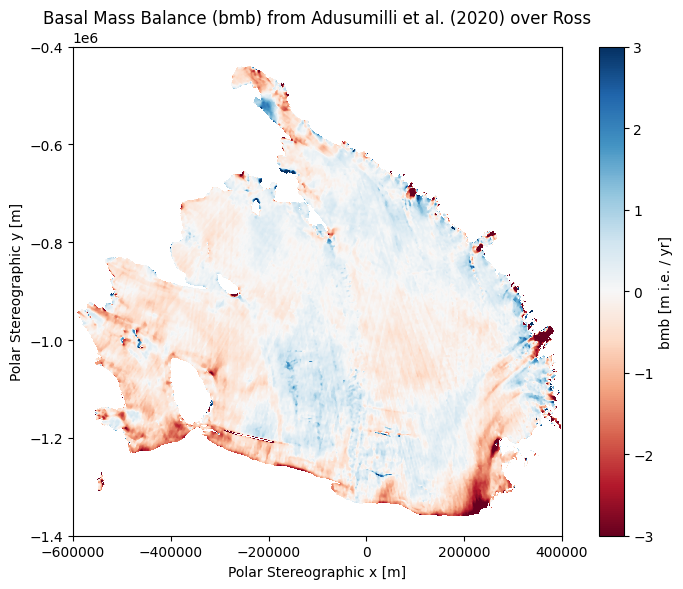

In [12]:
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    bmb_ross[0],
    bmb_ross[1],
    bmb_ross[2], 
    cmap = "RdBu",
    vmax = 3.0,
    vmin = - 3.0
)
plt.colorbar(pcm, label = "bmb [m i.e. / yr]")
plt.title("Basal Mass Balance (bmb) from Adusumilli et al. (2020) over Ross")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Interpolate at target grid

In [13]:
# Transform tensor to xarray DataArray for interpolation
x_np = x_t.detach().cpu().numpy()
y_np = y_t.detach().cpu().numpy()
bmb_np = bmb_t.detach().cpu().numpy()

bmb_da = xr.DataArray(
    bmb_np,
    dims = ("y", "x"),
    coords = {"x": x_np, "y": y_np},
    name = "bmb",
)

# Load target grid
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

# Interpolate bmb onto the target grid's x/y
bmb_on_target = bmb_da.interp(
    x = target_grid_mask["x"],
    y = target_grid_mask["y"],
    method = "linear",
)

# Mask out values outside of the target region
bmb_on_target_masked = bmb_on_target.where(target_grid_mask["mask"] > 0)

## Load MODIS background for visualisation

In [15]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

## Visualise

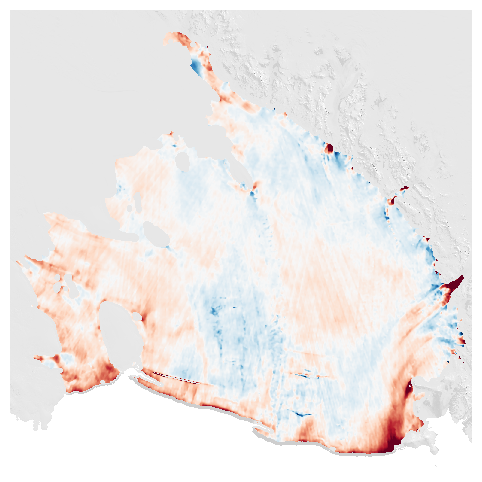

In [ ]:
vis_again = True

# Only rerun if needed
if vis_again :
    fig, ax = plt.subplots(figsize = (8, 6))

    # 1) MODIS as background (draw first)
    ax.pcolormesh(
        modis_ross[0],
        modis_ross[1], 
        modis_ross[2],
        cmap = "gray",
        # softer greys
        vmin = -30_000, 
        vmax = 30_000,
        # as less saturated background
        alpha = 0.4,
        zorder = 0,
    )

    # 2) SMB on top (draw second)
    pcm = ax.pcolormesh(
        bmb_on_target_masked.x,
        bmb_on_target_masked.y,
        bmb_on_target_masked,
        cmap = "RdBu",
        vmin = -3.0,
        vmax = 3.0,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()

    fig.savefig("figures/adusumilli_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
    plt.show()

# Add to combined xarray dataset

In [17]:
path = "data/fluxnet_div_ross.nc"

# 1) Open -> load into memory -> close file handle
with xr.open_dataset(path) as _ds:
    ds = _ds.load()

# 2) Add variable(s)
# NOTE: transpose
ds["adusumilli_bmb"] = (("y", "x"), bmb_on_target_masked.values.T)
ds["adusumilli_bmb"].attrs.update({
    "long_name": "Adusumilli basal mass balance on target grid",
    "units": "m yr-1",
})

# 3) Safe overwrite to SAME pathname (write temp, then atomic replace)
tmp_path = path + ".tmp"
ds.to_netcdf(tmp_path, mode = "w")
os.replace(tmp_path, path)